# 03 Baseline Saliency Grid

Generates all four saliency methods (vanilla gradients, guided backpropagation, GradCAM, integrated gradients) across a stratified sample of confidently-classified chest X-rays, producing a comparison grid figure. This is the "baseline" half of the sanity check - the cascade randomisation comparison follows after.

#### Setup

In [2]:
# Import libraries, project config, and the saliency/data functions built and tested in Notebook 02
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchxrayvision as xrv

import src.config as config
from src.data import load_and_preprocess_image
from src.saliency import (
    compute_vanilla_gradients,
    compute_guided_backprop,
    compute_gradcam,
    compute_integrated_gradients,
    compute_dataset_mean_baseline,
    overlay_saliency,
)

2.13.0+cpu
False


In [3]:
# Load the pretrained CheXpert DenseNet model
model = xrv.models.DenseNet(weights="densenet121-res224-chex")

In [4]:
# Load the 250-image label set, including the true-label prediction probabilities computed in Notebook 01
labels = pd.read_csv('../data/true_probability_labels.csv')
labels[labels['True Label Probability'] >= 0.7]['Finding Labels'].value_counts()

Finding Labels
Effusion        37
Atelectasis     23
Cardiomegaly    16
Pneumonia        2
Name: count, dtype: int64

**Note on image selection:** Pneumothorax is excluded from this grid entirely - no images in the 250-image sample reached the ≥0.7 confidence threshold for this pathology (consistent with the domain-shift finding in `01_setup.ipynb`). Pneumonia is capped at 2 images (its only 2 confidently-classified cases), rather than the target of 3 per class used for the other pathologies.

In [5]:
# Select a stratified sample of confidently-classified images (≥0.7 true-label probability), 3 per pathology where available
sampled_grid_images = []
grid_pathologies = ['Cardiomegaly', 'Effusion', 'Pneumonia', 'Atelectasis']  # Pneumothorax excluded - see note

for pathology in grid_pathologies:
    condition = (labels['Finding Labels'] == pathology) & (labels['True Label Probability'] >= 0.7)
    filtered = labels[condition]
    n_available = len(filtered)
    n_sample = min(3, n_available)  # take 3, or fewer if not enough available
    sample = filtered.sample(n=n_sample, random_state=config.SEED)
    sampled_grid_images.append(sample)

grid_images = pd.concat(sampled_grid_images)
print(len(grid_images))
grid_images['Finding Labels'].value_counts()

11


Finding Labels
Cardiomegaly    3
Effusion        3
Atelectasis     3
Pneumonia       2
Name: count, dtype: int64

torch.Size([1, 1, 224, 224]) -903.4296264648438 692.5464477539062


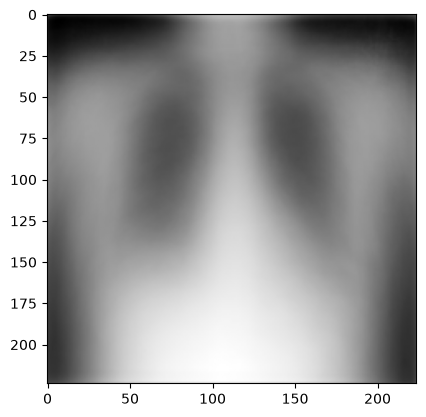

In [6]:
# Recompute the dataset-mean baseline image, used as the Integrated Gradients reference point
sampled_data_labels = pd.read_csv('../data/sampled_data_labels.csv')
baseline = compute_dataset_mean_baseline(sampled_data_labels['Image Index'].tolist(), '../data/xray_dataset')
print(baseline.shape, baseline.min().item(), baseline.max().item())
plt.imshow(baseline.squeeze().detach().numpy(), cmap='gray')

In [7]:
# Wrapping all four saliency map methods in one function for reuse
methods = {
    'Vanilla Gradients': lambda model, img, target: compute_vanilla_gradients(model, img, target),
    'Guided Backprop': lambda model, img, target: compute_guided_backprop(model, img, target),
    'GradCAM': lambda model, img, target: compute_gradcam(model, img, target, model.features.denseblock4),
    'Integrated Gradients': lambda model, img, target: compute_integrated_gradients(model, img, target, baseline, n_steps=20),
}

results = []  # list of dicts: {filename, pathology, base_img, saliency_maps: {method_name: array}}

#### Saliency maps
Generate all four saliency maps for each of the selected images (2x Pneumonia, 3x Effusion, Atelectasis, Cardiomegaly), storing the base image and per-method attribution maps for use in the grid figure below.

In [8]:
for _, row in grid_images.iterrows():
    filename = row['Image Index']
    pathology = row['Finding Labels']

    img = load_and_preprocess_image(f"../data/xray_dataset/{filename}")
    img.requires_grad_()
    target_class = model.pathologies.index(pathology)

    base_img = img.squeeze().detach().numpy()

    saliency_maps = {}
    for method_name, method_fn in methods.items():
        saliency_maps[method_name] = method_fn(model, img, target_class)

    results.append({
        'filename': filename,
        'pathology': pathology,
        'base_img': base_img,
        'saliency_maps': saliency_maps,
    })

    print(f"Done: {filename} ({pathology})")

torch.Size([1, 1, 7, 7]) tensor(-0.0017, grad_fn=<MinBackward1>) tensor(0.0072, grad_fn=<MaxBackward1>)
Done: 00002038_001.png (Cardiomegaly)
torch.Size([1, 1, 7, 7]) tensor(-0.0003, grad_fn=<MinBackward1>) tensor(0.0041, grad_fn=<MaxBackward1>)
Done: 00015770_011.png (Cardiomegaly)
torch.Size([1, 1, 7, 7]) tensor(-0.0025, grad_fn=<MinBackward1>) tensor(0.0080, grad_fn=<MaxBackward1>)
Done: 00010994_011.png (Cardiomegaly)
torch.Size([1, 1, 7, 7]) tensor(-0.0084, grad_fn=<MinBackward1>) tensor(0.0078, grad_fn=<MaxBackward1>)
Done: 00014153_000.png (Effusion)
torch.Size([1, 1, 7, 7]) tensor(-0.0049, grad_fn=<MinBackward1>) tensor(0.0038, grad_fn=<MaxBackward1>)
Done: 00002791_001.png (Effusion)
torch.Size([1, 1, 7, 7]) tensor(-0.0106, grad_fn=<MinBackward1>) tensor(0.0037, grad_fn=<MaxBackward1>)
Done: 00014675_000.png (Effusion)
torch.Size([1, 1, 7, 7]) tensor(-0.0018, grad_fn=<MinBackward1>) tensor(0.0129, grad_fn=<MaxBackward1>)
Done: 00010384_035.png (Pneumonia)
torch.Size([1, 1, 7, 

Build an 11×4 grid (rows = images, columns = methods), overlaying each saliency map on its original X-ray, and save the figure to `figures/baseline_saliency_grid.png`.

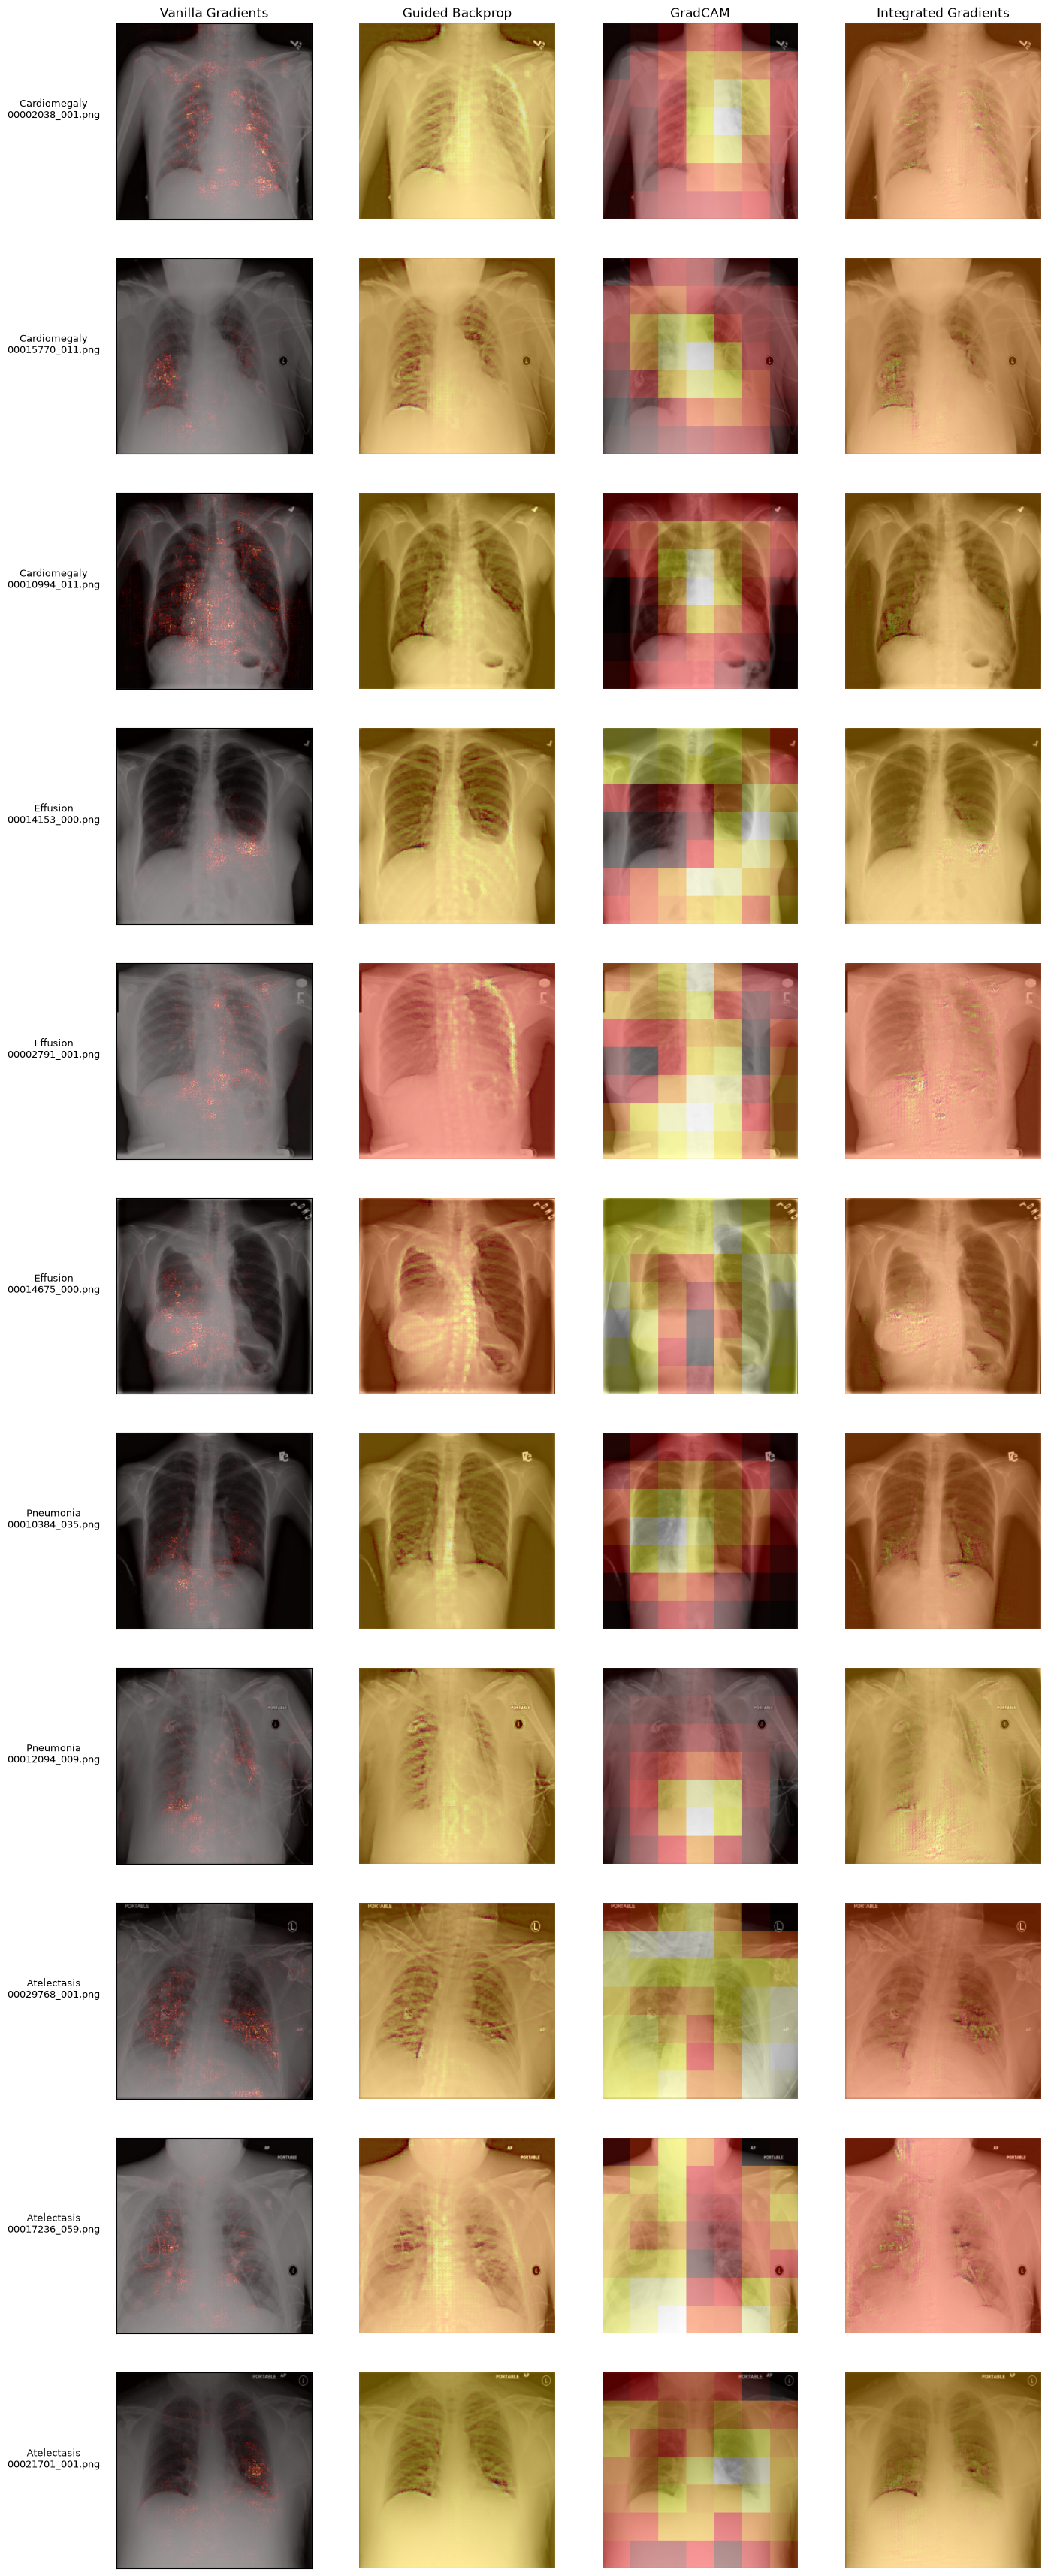

In [9]:
n_images = len(results)
n_methods = len(methods)  # 4

fig, axes = plt.subplots(
    nrows=n_images,
    ncols=n_methods,
    figsize=(4 * n_methods, 4 * n_images)
)

method_names = list(methods.keys())

# Loop through the x-ray image set and apply each saliency map method, before adding it to the plot
for row_idx, result in enumerate(results):
    base_img = result['base_img']
    for col_idx, method_name in enumerate(method_names):
        saliency_map = result['saliency_maps'][method_name]
        ax = axes[row_idx, col_idx]

        ax.imshow(base_img, cmap='gray')
        ax.imshow(saliency_map, cmap='hot', alpha=0.4)
        ax.axis('off')

        # Column headers, only on the top row
        if row_idx == 0:
            ax.set_title(method_name, fontsize=12)

        # Row labels, only on the leftmost column
        if col_idx == 0:
            ax.set_ylabel(f"{result['pathology']}\n{result['filename']}", fontsize=9, rotation=0, labelpad=60)
            ax.axis('on')  # need axis on to show the ylabel, but hide ticks
            ax.set_xticks([])
            ax.set_yticks([])

In [13]:
plt.tight_layout()
fig.savefig('../figures/baseline_saliency_grid.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

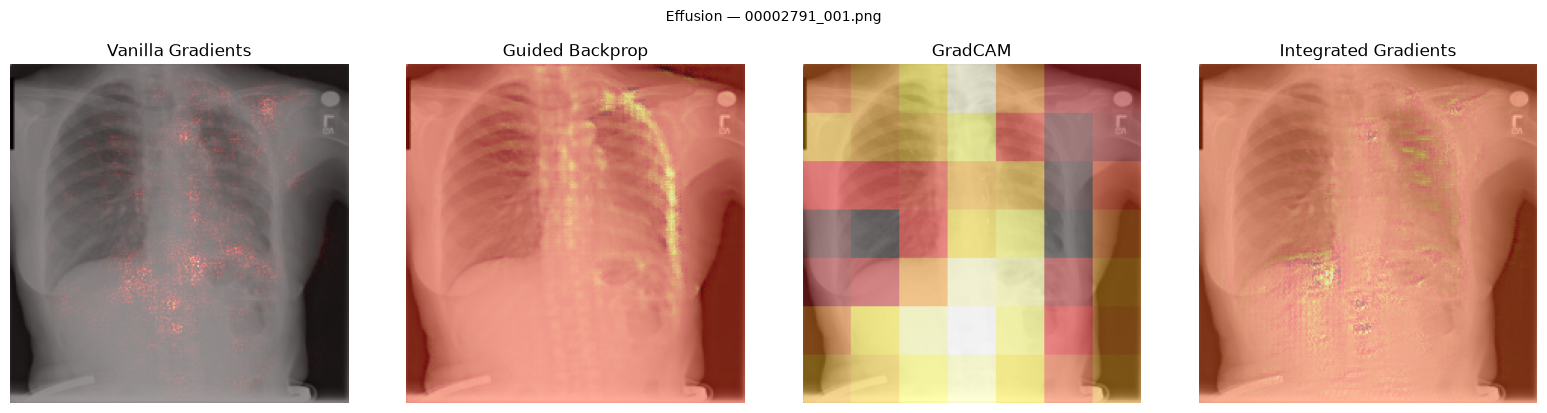

In [16]:
# Pick one image's results to feature as a header image for README
featured = results[4]

fig, axes = plt.subplots(1, len(method_names), figsize=(4 * len(method_names), 4))

for col_idx, method_name in enumerate(method_names):
    ax = axes[col_idx]
    ax.imshow(featured['base_img'], cmap='gray')
    ax.imshow(featured['saliency_maps'][method_name], cmap='hot', alpha=0.4)
    ax.set_title(method_name, fontsize=12)
    ax.axis('off')

fig.suptitle(f"{featured['pathology']} — {featured['filename']}", fontsize=10, y=1.02)
plt.tight_layout()
fig.savefig('../figures/header_saliency_example.png', dpi=150, bbox_inches='tight')
plt.show()

**Initial visual observations:**

- The four methods look visibly different from one another on the same image, with Guided Backprop and Integrated Gradients sharing the most similarity in some images
- GradCAM appears noticeably coarser/blockier than the pixel-level methods (Vanilla, Guided Backprop, Integrated Gradients)
- Vanilla Gradients resembles the raw anatomy of the X-ray image itself the most out of the methods, regardless of pathology
